# Section 3: System Characterization
Quantitative metrics: consistency, conditional Lyapunov exponent, power spectral density,
linear memory capacity, information processing capacity, and measure of nonlinearity.
Observational orthogonality reported alongside each test.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
from itertools import combinations_with_replacement
import json, os
from prc_toolkit.config import FS, DT, V_MAX, N_TRIALS, RESULTS_DIR
from prc_toolkit.dut.base import to_input_seq
from prc_toolkit.dut.factory import make_dut, prepare_input
from prc_toolkit.dut.ag2s_nwn import RECOMMENDED_PARAMS   # for switching to Ag2S-NWN
from prc_toolkit.signals.generators import iid_uniform
from prc_toolkit.analysis.readout import train_readout_ridge, predict_readout, r_squared, nrmse
from prc_toolkit.analysis.orthogonality import observational_orthogonality
from prc_toolkit.utils.settling import run_until_settled

In [2]:
# ── Load from previous sections ────────────────────────
with open(os.path.join(RESULTS_DIR, "section1_results.json")) as f:
    s1 = json.load(f)
with open(os.path.join(RESULTS_DIR, "section2_results.json")) as f:
    s2 = json.load(f)

V_SAFE     = s1["V_SAFE"]
DUT_PARAMS = s1["DUT_params"]  # for Ag2S-NWN, use RECOMMENDED_PARAMS instead (see prc_toolkit.dut.ag2s_nwn)
# DUT_PARAMS = RECOMMENDED_PARAMS  # Uncomment to switch to Ag2S-NWN
print(f"V_safe = {V_SAFE:.3f}")

# ── DUT selection: "liesn" (default), "ag2s_nwn", or "hardware" ─────────
DUT_MODEL = "liesn"
# DUT_MODEL = "ag2s_nwn"
# DUT_MODEL = "hardware"

# True whenever DUT_MODEL == "hardware" -- suppresses simulation-only
# outputs (e.g. Column D of the visual fingerprint, unavailable on real
# hardware).
HARDWARE_MODE = (DUT_MODEL == "hardware")

# Pre-recorded output CSVs are loaded from here when DUT_MODEL == "hardware".
# Defaults to the committed demo dataset so hardware mode works without real
# hardware attached; point this at data/hardware/outputs once you've recorded
# real data via 00_hardware_signals.ipynb.
HARDWARE_DATA_PATH = "data/demo/hardware_outputs"

# Set True (with DUT_MODEL="liesn") to regenerate data/demo/hardware_outputs/,
# then set back to False.
SAVE_DEMO_HARDWARE_DATA = False

# ── Section 3 parameters ───────────────────────────────
SIGNAL_DURATION  = 30.0    # Seconds of i.i.d. uniform input for shared run
SETTLE_DURATION  = 5.0     # Seconds of settling before recording
K_MAX            = 50      # Maximum delay for MC and IPC (samples)
IPC_MAX_DEGREE   = 3       # Maximum polynomial degree for IPC
SEED_UNIFORM_0   = 99      # Seed for trial 0 input
SEED_UNIFORM_1   = 100     # Seed for trial 1 input (different initial conditions only;
                            # both trials receive IDENTICAL u after settling)

V_safe = 0.800


In [3]:
assert DUT_MODEL in ("liesn", "ag2s_nwn", "hardware"), (
    f"DUT_MODEL '{DUT_MODEL}' is not supported in this notebook. "
    f"Supported values: 'liesn', 'ag2s_nwn', 'hardware'."
)

# ── Instantiate DUT ─────────────────────────────────────
dut = make_dut(DUT_MODEL, DUT_PARAMS)

In [4]:
# ── Hardware I/O helpers ─────────────────────────────────
# Plain stdlib csv module, not pandas -- this toolkit has no pandas
# dependency (see 04_benchmarks.ipynb's sunspot loader for precedent).
import csv
from pathlib import Path

def load_hardware_output(filename: str) -> np.ndarray:
    """
    Load a pre-recorded hardware output CSV from HARDWARE_DATA_PATH.

    Expected format:
      - Header row with column names h0, h1, h2, ... (one per output electrode)
      - One row per timestep
      - Values are floating-point voltage readings

    Returns H: array, shape (T, N_h).

    If the file is not found, raises FileNotFoundError with a helpful message
    directing the operator to 00_hardware_signals.ipynb for recording instructions.
    """
    path = Path(HARDWARE_DATA_PATH) / filename
    if not path.exists():
        raise FileNotFoundError(
            f"Hardware output file not found: {path}\n"
            f"Run 00_hardware_signals.ipynb and follow the recording instructions "
            f"to generate this file before running this notebook."
        )
    with open(path, newline="") as f:
        reader = csv.reader(f)
        next(reader)  # header row (h0, h1, ...)
        rows = [[float(v) for v in row] for row in reader]
    return np.array(rows, dtype=float)


DEMO_DATA_PATH = Path("data/demo/hardware_outputs")

def save_hardware_demo(filename: str, H: np.ndarray):
    """
    Save H into the committed demo dataset (data/demo/hardware_outputs/) so
    that DUT_MODEL="hardware" works out of the box without real hardware.
    No-op unless SAVE_DEMO_HARDWARE_DATA = False. Regenerate the demo dataset
    by re-running this notebook with DUT_MODEL="liesn" and
    SAVE_DEMO_HARDWARE_DATA=True.
    """
    if not SAVE_DEMO_HARDWARE_DATA:
        return
    DEMO_DATA_PATH.mkdir(parents=True, exist_ok=True)
    header = [f"h{i}" for i in range(H.shape[1])]
    with open(DEMO_DATA_PATH / filename, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(header)
        writer.writerows(H.tolist())


## Shared Input: Two Trials from Different Initial Conditions

Both trials receive the same i.i.d. uniform random driving sequence after settling.
Trial 0 and Trial 1 differ only in their initial conditions (established by a brief
distinct settling input before the main sequence begins).

**I/O convention for all Section 3 tests:**
- u(t): scalar input, shape (T,). Single-channel drive.
- H(t): vector output, shape (T, N_h). Full electrode vector used for orthogonality
  and readout training.
- h_scalar(t): ‖H‖₂ rowwise, shape (T,). Used for CLE, PSD, and NL measure.

In [5]:
# ── Generate shared driving input (identical for both trials) ───
T_sig  = int(SIGNAL_DURATION * FS)
u_drive = iid_uniform(duration=SIGNAL_DURATION, amplitude=V_SAFE, fs=FS, seed=SEED_UNIFORM_0)
u_drive = prepare_input(u_drive, V_SAFE, DUT_MODEL)

# ── Trial 0: initial condition from random state A ───────
u_settle_A = iid_uniform(duration=SETTLE_DURATION, amplitude=V_SAFE*0.3, fs=FS, seed=1001)
u_settle_A = prepare_input(u_settle_A, V_SAFE*0.3, DUT_MODEL)

# --- Data collection (trial 0) ---
if DUT_MODEL == "hardware":
    H0 = load_hardware_output("section3_shared_run_trial00.csv")
else:
    dut.reset()
    dut.run(to_input_seq(u_settle_A))    # drive to initial state A; discard output
    H0 = dut.run(to_input_seq(u_drive))  # shape (T_sig, N_h) — full electrode vector, trial 0
    save_hardware_demo("section3_shared_run_trial00.csv", H0)
h0_scalar = np.linalg.norm(H0, axis=1)  # shape (T_sig,) scalar

# ── Trial 1: initial condition from random state B ───────
u_settle_B = iid_uniform(duration=SETTLE_DURATION, amplitude=V_SAFE*0.3, fs=FS, seed=1002)
u_settle_B = prepare_input(u_settle_B, V_SAFE*0.3, DUT_MODEL)

# --- Data collection (trial 1) ---
if DUT_MODEL == "hardware":
    H1 = load_hardware_output("section3_shared_run_trial01.csv")
else:
    dut.reset()
    dut.run(to_input_seq(u_settle_B))    # drive to initial state B; discard output
    H1 = dut.run(to_input_seq(u_drive))  # shape (T_sig, N_h) — full electrode vector, trial 1
    save_hardware_demo("section3_shared_run_trial01.csv", H1)
h1_scalar = np.linalg.norm(H1, axis=1)  # shape (T_sig,) scalar

ortho_shared = observational_orthogonality(H0)
print(f"Observational orthogonality (shared run, trial 0): {ortho_shared:.4f}")
print(f"Trial data shape: H0={H0.shape}, H1={H1.shape}")

Observational orthogonality (shared run, trial 0): 0.2151
Trial data shape: H0=(3000, 5), H1=(3000, 5)


## 3.2 Consistency

Consistency measures how reproducible the reservoir's response is to the same input
from different initial conditions. Computed as the time-averaged Pearson correlation
coefficient between the two trial outputs, per electrode, then averaged globally.

γ² ∈ [0, 1]. γ² ≈ 1 → highly consistent (supports ESP). γ² ≈ 0 → chaotic or noisy.

**I/O:** Uses full electrode vector H0, H1 shape (T, N_h).
Per-electrode γ²_i reported, plus global scalar γ².

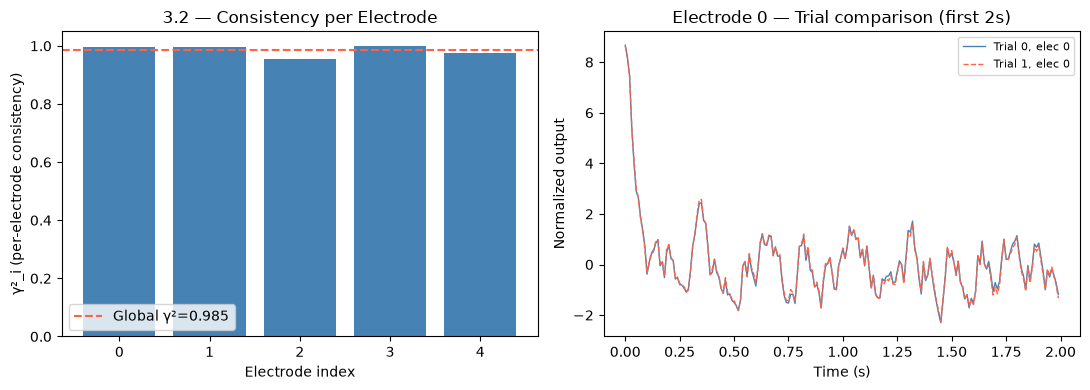

Global consistency γ² = 0.9847
Per-electrode γ²: [0.9973 0.9977 0.955  0.9994 0.9739]


In [6]:
# ── 3.2 Consistency ─────────────────────────────────────
# Uses full vector outputs H0, H1 — one value per electrode per timestep.

def normalize_trial(H):
    """Zero-mean, unit-variance normalization per electrode column."""
    mu = H.mean(axis=0, keepdims=True)
    sigma = H.std(axis=0, keepdims=True) + 1e-12
    return (H - mu) / sigma

H0_norm = normalize_trial(H0)   # shape (T, N_h)
H1_norm = normalize_trial(H1)   # shape (T, N_h)

# Per-electrode Pearson consistency
gamma2_per = np.mean(H0_norm * H1_norm, axis=0)   # shape (N_h,)
gamma2_global = float(np.mean(gamma2_per))

# ── Plot ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(range(len(gamma2_per)), gamma2_per, color='steelblue')
axes[0].axhline(gamma2_global, color='tomato', ls='--', lw=1.5, label=f'Global γ²={gamma2_global:.3f}')
axes[0].set_xlabel("Electrode index")
axes[0].set_ylabel("γ²_i (per-electrode consistency)")
axes[0].set_title("3.2 — Consistency per Electrode")
axes[0].set_ylim([0, 1.05])
axes[0].legend()

# Time series comparison (electrode 0)
t_sig = np.arange(T_sig) * DT
axes[1].plot(t_sig[:200], H0_norm[:200, 0], color='steelblue', lw=1, label='Trial 0, elec 0')
axes[1].plot(t_sig[:200], H1_norm[:200, 0], color='tomato',    lw=1, label='Trial 1, elec 0', ls='--')
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Normalized output")
axes[1].set_title("Electrode 0 — Trial comparison (first 2s)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Global consistency γ² = {gamma2_global:.4f}")
print(f"Per-electrode γ²: {np.round(gamma2_per, 4)}")

## 3.3.1 Conditional Lyapunov Exponent (CLE)

The CLE estimates whether trajectories from two different initial conditions converge
(ordered, λ̂ < 0), neither converge nor diverge (critical, λ̂ ≈ 0), or diverge (chaotic, λ̂ > 0).

Computed by fitting an exponential model to ‖μ(t)‖ = ‖h⁽⁰⁾(t) − h⁽¹⁾(t)‖ via OLS on log scale.
The goodness of fit R² is reported as a validity check.

**I/O:** Uses scalar outputs h0_scalar, h1_scalar. d(t) = |h0(t) − h1(t)|.

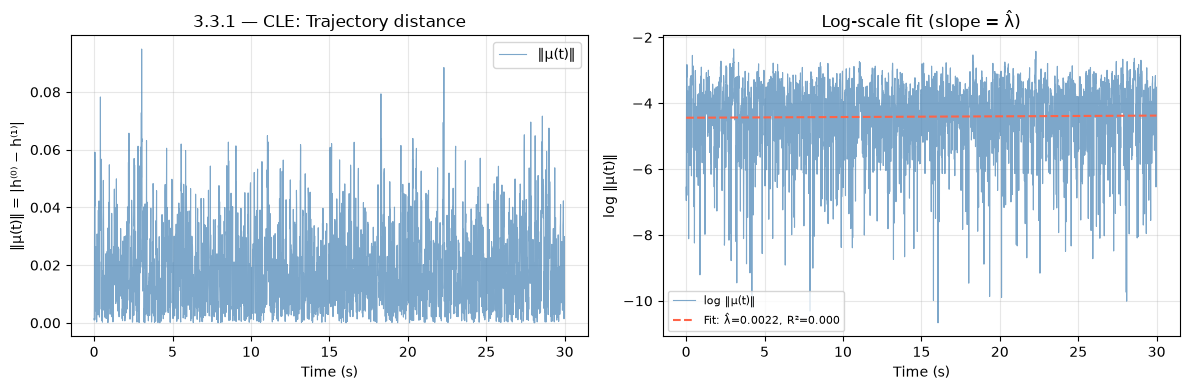

λ̂ = 0.00216  |  R² = 0.0003  |  Regime: critical/edge


In [7]:
# ── 3.3.1 Conditional Lyapunov Exponent ──────────────────
# Scalar input: h0_scalar and h1_scalar, shape (T,).
# d(t) = |h0(t) - h1(t)|  scalar trajectory distance

d_cle = np.abs(h0_scalar - h1_scalar) + 1e-12   # avoid log(0)
log_d = np.log(d_cle)
t_cle = np.arange(T_sig) * DT

# OLS fit: log_d = λ·t + ln(c)
t_mean   = t_cle.mean()
ld_mean  = log_d.mean()
num      = np.sum((t_cle - t_mean) * (log_d - ld_mean))
den      = np.sum((t_cle - t_mean)**2)
lambda_hat = num / den
ln_c       = ld_mean - lambda_hat * t_mean

log_d_fit = lambda_hat * t_cle + ln_c
ss_res = np.sum((log_d - log_d_fit)**2)
ss_tot = np.sum((log_d - ld_mean)**2)
R2_cle = float(1 - ss_res / (ss_tot + 1e-12))

# ── Plot ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t_cle, d_cle, color='steelblue', lw=0.8, alpha=0.7, label='‖μ(t)‖')
axes[0].set_xlabel("Time (s)"); axes[0].set_ylabel("‖μ(t)‖ = |h⁽⁰⁾ − h⁽¹⁾|")
axes[0].set_title("3.3.1 — CLE: Trajectory distance")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(t_cle, log_d,    color='steelblue', lw=0.8, alpha=0.7, label='log ‖μ(t)‖')
axes[1].plot(t_cle, log_d_fit, color='tomato',   lw=1.5, ls='--',
             label=f'Fit: λ̂={lambda_hat:.4f}, R²={R2_cle:.3f}')
axes[1].set_xlabel("Time (s)"); axes[1].set_ylabel("log ‖μ(t)‖")
axes[1].set_title("Log-scale fit (slope = λ̂)")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

regime = "ordered" if lambda_hat < -0.05 else ("chaotic" if lambda_hat > 0.05 else "critical/edge")
print(f"λ̂ = {lambda_hat:.5f}  |  R² = {R2_cle:.4f}  |  Regime: {regime}")
if R2_cle < 0.5:
    print("Warning: Low R² — exponential model is a poor fit. Interpret λ̂ cautiously.")

## 3.3.2 Power Spectral Density vs 1/f Spectrum

The PSD of the reservoir output is estimated via Welch's method (overlapping windowed FFTs)
applied to trial 0's scalar output h0_scalar. A 1/f power law is fit via linear regression
on the log-log PSD, giving exponent β̂ and fit quality R².

β̂ ≈ 1 → canonical 1/f, associated with critical dynamics.
β̂ ≈ 2 → random-walk-like, associated with chaotic dynamics.

**I/O:** Scalar output h0_scalar, shape (T,). Reuses trial 0 data from shared run.
No new DUT run required.

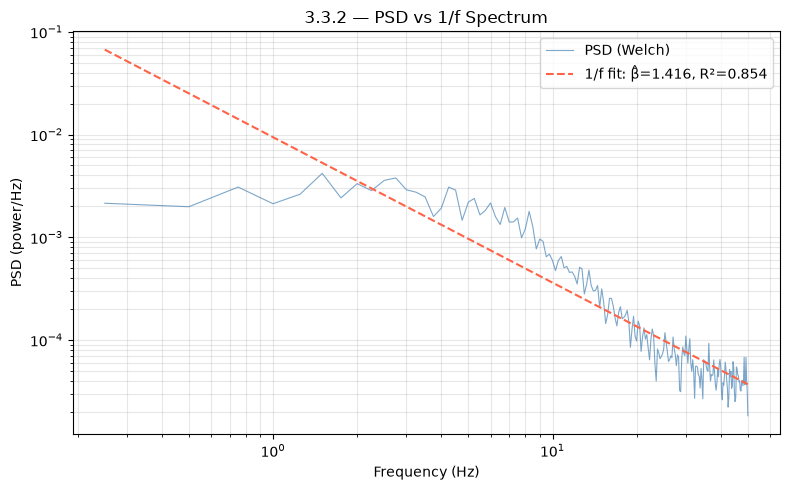

β̂ = 1.4161  |  R² = 0.8541
β̂ ≈ 1: critical dynamics.  β̂ ≈ 2: chaotic/random-walk dynamics.


In [8]:
# ── 3.3.2 PSD vs 1/f Spectrum ──────────────────────────
# Input: scalar h0_scalar, shape (T,). Uses Welch's method via scipy.

freqs_psd, psd = welch(
    h0_scalar,
    fs=FS,
    window='hann',
    nperseg=FS * 4,      # 4-second segments
    noverlap=FS * 2,     # 50% overlap
    scaling='density'
)

# Exclude DC (freq=0) for log-log fit
mask = freqs_psd > 0
f_fit  = freqs_psd[mask]
psd_fit = psd[mask]

log_f   = np.log10(f_fit)
log_psd = np.log10(psd_fit + 1e-30)

# OLS on log-log: log_psd = -β·log_f + C
lf_mean  = log_f.mean()
lp_mean  = log_psd.mean()
num_psd  = np.sum((log_f - lf_mean) * (log_psd - lp_mean))
den_psd  = np.sum((log_f - lf_mean)**2)
neg_beta = num_psd / den_psd
beta_hat = -neg_beta
C_fit    = lp_mean - neg_beta * lf_mean

log_psd_fit = neg_beta * log_f + C_fit
ss_res_psd  = np.sum((log_psd - log_psd_fit)**2)
ss_tot_psd  = np.sum((log_psd - lp_mean)**2)
R2_psd      = float(1 - ss_res_psd / (ss_tot_psd + 1e-12))

# ── Plot ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(f_fit, psd_fit, color='steelblue', lw=0.8, alpha=0.7, label='PSD (Welch)')
ax.loglog(f_fit, 10**log_psd_fit, color='tomato', lw=1.5, ls='--',
          label=f'1/f fit: β̂={beta_hat:.3f}, R²={R2_psd:.3f}')
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("PSD (power/Hz)")
ax.set_title("3.3.2 — PSD vs 1/f Spectrum")
ax.legend()
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

print(f"β̂ = {beta_hat:.4f}  |  R² = {R2_psd:.4f}")
print("β̂ ≈ 1: critical dynamics.  β̂ ≈ 2: chaotic/random-walk dynamics.")

## 3.4 Linear Memory Capacity (MC)

MC quantifies the reservoir's ability to reconstruct past inputs at increasing delays k.
A trained linear readout (OLS) maps the electrode outputs H to the delayed input u(t−k).
MC_k = R²(u(t−k), ŷ(t−k)). Total MC = Σ MC_k.

A smooth decay of MC_k with k indicates healthy fading memory.

**I/O:**
- Readout training: H0 shape (T, N_h) — full electrode vector as readout input.
- Targets: scalar delayed input u(t−k), shape (T,) per delay k.
- MC_k is a scalar per delay. Total MC is a scalar.

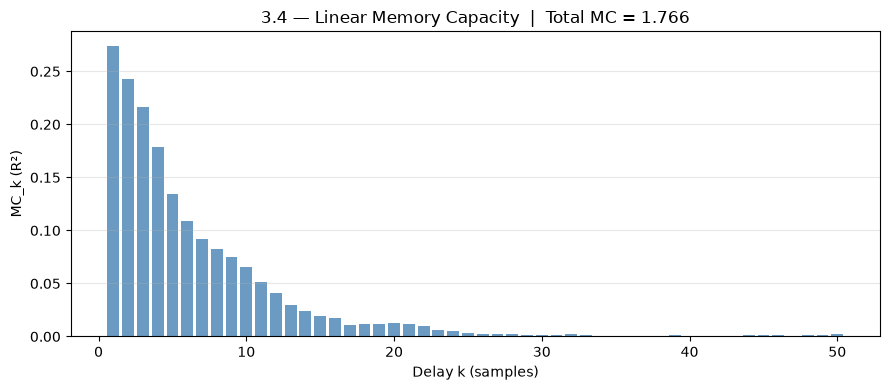

Total MC = 1.7658
Observational orthogonality: 0.2151


In [9]:
# ── 3.4 Linear Memory Capacity ──────────────────────────
# Uses full electrode vector H0 (T, N_h) as readout input.
# Target per delay k: u_drive[t - k], scalar.

T = H0.shape[0]

# Build target matrix U: column k is u(t-k) for k=1..K_MAX
U_targets = np.zeros((T, K_MAX))
for k in range(1, K_MAX + 1):
    U_targets[:, k-1] = np.roll(u_drive, k)  # shift right by k
    U_targets[:k, k-1] = 0.0  # zero-pad initial samples

# Train readout once for all delays (efficient batch solve).
# Ridge regression used for numerical stability (H may be near-singular).
W_mc = train_readout_ridge(H0, U_targets)   # shape (N_h + 1, K_MAX); last row is intercept
U_pred = predict_readout(H0, W_mc)      # shape (T, K_MAX)

# MC_k = R² between target and prediction for each delay
MC_k = np.array([
    r_squared(U_targets[:, k], U_pred[:, k])
    for k in range(K_MAX)
])
MC_total = float(MC_k.sum())

# ── Plot ────────────────────────────────────────────────
delays = np.arange(1, K_MAX + 1)
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(delays, MC_k, color='steelblue', alpha=0.8)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel("Delay k (samples)")
ax.set_ylabel("MC_k (R²)")
ax.set_title(f"3.4 — Linear Memory Capacity  |  Total MC = {MC_total:.3f}")
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

ortho_mc = float(observational_orthogonality(H0))
print(f"Total MC = {MC_total:.4f}")
print(f"Observational orthogonality: {ortho_mc:.4f}")

## 3.5 Information Processing Capacity (IPC)

IPC extends MC by testing the reservoir's ability to reconstruct nonlinear polynomial
functions of past inputs. Basis functions are products of normalized Legendre polynomials
P_n(u(t−j)) across delays j and degrees n.

At degree d=1, IPC recovers linear MC exactly.
At d≥2, cross-delay and higher-order terms capture nonlinear memory.

**I/O:**
- Readout input: H0 shape (T, N_h) — full electrode vector.
- Targets: polynomial basis functions z_α(t), scalar per basis index α.
- IPC_α is a scalar. Total IPC = Σ IPC_α (summed over all α).

Number of IPC basis functions: 23425


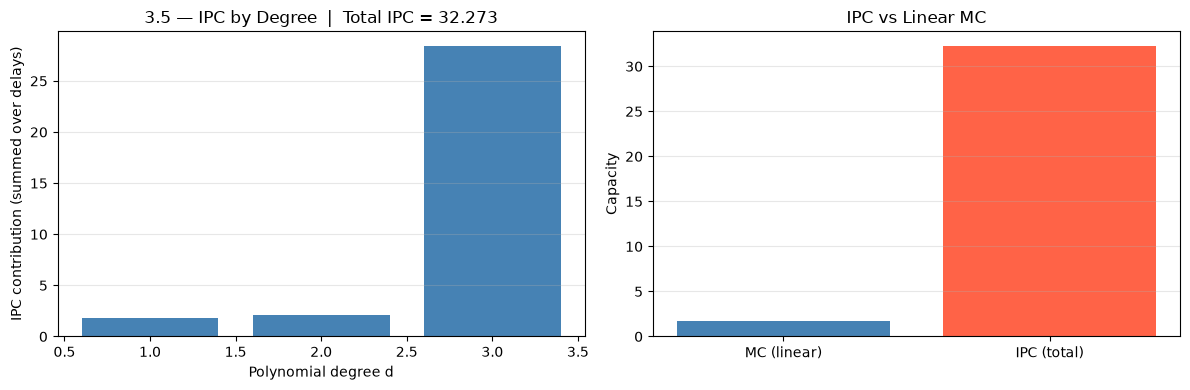

Total IPC = 32.2727
IPC by degree: {1: np.float64(1.7658), 2: np.float64(2.0777), 3: np.float64(28.4292)}
(d=1 should match MC ≈ 1.7658)


In [10]:
# ── 3.5 Information Processing Capacity (IPC) ────────────
from collections import Counter
# NOTE: N_basis grows as C(K_MAX + d, d) summed over d=1..IPC_MAX_DEGREE. With
# K_MAX=50 and IPC_MAX_DEGREE=3 this is ~23,000 basis functions — a large but
# tractable batch solve (ridge is a 5x5 system regardless of N_basis; building
# Z_targets and the R² loop below are the dominant cost, a few seconds each).
# For quicker iteration while developing, reduce K_MAX to 10 or
# IPC_MAX_DEGREE to 2 (see prompts/03_system_characterization.md notes).

def legendre_normalized(n, x):
    """Normalized Legendre polynomial P̃_n(x), orthonormal on U[-1,1].
    Only degrees 0..IPC_MAX_DEGREE are ever requested."""
    assert 0 <= n <= IPC_MAX_DEGREE, f"Legendre degree {n} exceeds IPC_MAX_DEGREE={IPC_MAX_DEGREE}"
    if n == 0: return np.full_like(x, np.sqrt(0.5))
    elif n == 1: return np.sqrt(1.5) * x
    elif n == 2: return np.sqrt(2.5) * 0.5 * (3*x**2 - 1)
    elif n == 3: return np.sqrt(3.5) * 0.5 * (5*x**3 - 3*x)
    elif n == 4: return np.sqrt(4.5) * 0.125 * (35*x**4 - 30*x**2 + 3)
    else:
        raise ValueError(f"Legendre degree {n} not implemented. Add more terms.")

# Normalize u_drive to [-1, 1]
# NOTE: if DUT_MODEL='ag2s_nwn', u_drive is non-negative (bias_positive'd),
# so this actually lands in [0, 1]. Legendre basis functions remain
# well-defined there, but are no longer orthonormal over the full [-1,1]
# interval as intended for this DUT. See build_notes.md.
u_norm = np.clip(u_drive / V_SAFE, -1, 1)

# Generate all multi-indices α = (α_1, ..., α_K_MAX) with Σα_j = d, α_j ≥ 0
# Only non-trivial (d ≥ 1) and up to IPC_MAX_DEGREE.
# For efficiency, limit to non-zero entries only (sparse representation).

def generate_multi_indices(k_max, d_max):
    """
    Generate all multi-indices for IPC basis functions.
    Uses combinations_with_replacement for efficiency — avoids the exponential
    blowup of itertools.product. Each multi-index is a tuple of delay indices
    (with repetition) of length 1..d_max, representing which delays contribute.

    For example, (0, 2) means delays j=1 and j=3 each contribute degree 1,
    giving a cross-term P_1(u(t-1)) * P_1(u(t-3)).

    Returns list of tuples, each representing active delay indices.
    The corresponding alpha vector has alpha[j] = count of j in tuple.
    """
    indices = []
    for d in range(1, d_max + 1):
        # All combinations of d delay indices from {0, 1, ..., k_max-1} with repetition
        for combo in combinations_with_replacement(range(k_max), d):
            indices.append(combo)
    return indices

multi_indices = generate_multi_indices(K_MAX, IPC_MAX_DEGREE)
N_basis = len(multi_indices)
print(f"Number of IPC basis functions: {N_basis}")
if N_basis > 500:
    print(f"WARNING: N_basis={N_basis} is large. Building the target matrix and "
          f"the per-basis R² loop may take a while. Consider reducing K_MAX or "
          f"IPC_MAX_DEGREE for faster iteration.")

# Build basis target matrix Z: each column is z_α(t)
# multi_indices entries are tuples of delay indices (0-based), with repetition.
# Degree d = len(combo). alpha_j = number of times delay j appears in combo.
Z_targets = np.zeros((T, N_basis))
for col_idx, combo in enumerate(multi_indices):
    z = np.ones(T)
    # Count occurrences of each delay index to get per-delay degree
    delay_counts = Counter(combo)
    for delay_idx, degree in delay_counts.items():
        k = delay_idx + 1   # convert 0-based index to 1-based delay
        u_delayed = np.roll(u_norm, k)
        u_delayed[:k] = 0.0
        z *= legendre_normalized(degree, u_delayed)
    Z_targets[:, col_idx] = z

# Train readout and compute IPC_α
# NOTE: train_readout_ridge's own solve is small (N_h x N_h regardless of
# N_basis), but np.linalg.lstsq-based OLS readouts would not scale as well
# for large N_basis — ridge is used here deliberately. No further
# optimization is applied in this iteration.
W_ipc  = train_readout_ridge(H0, Z_targets)  # shape (N_h + 1, N_basis); last row is intercept
Z_pred = predict_readout(H0, W_ipc)       # shape (T, N_basis)

IPC_alpha = np.array([
    r_squared(Z_targets[:, i], Z_pred[:, i])
    for i in range(N_basis)
])
IPC_total = float(np.clip(IPC_alpha, 0, None).sum())

# ── Aggregate by degree ─────────────────────────────────
IPC_by_degree = {}
for col_idx, combo in enumerate(multi_indices):
    d = len(combo)   # degree = number of delay indices in the combination
    IPC_by_degree.setdefault(d, []).append(max(0.0, IPC_alpha[col_idx]))

IPC_degree_totals = {d: sum(v) for d, v in IPC_by_degree.items()}

# ── Plot ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

degrees = sorted(IPC_degree_totals.keys())
axes[0].bar(degrees, [IPC_degree_totals[d] for d in degrees], color='steelblue')
axes[0].set_xlabel("Polynomial degree d")
axes[0].set_ylabel("IPC contribution (summed over delays)")
axes[0].set_title(f"3.5 — IPC by Degree  |  Total IPC = {IPC_total:.3f}")
axes[0].grid(True, alpha=0.3, axis='y')

# IPC vs MC comparison
axes[1].bar(['MC (linear)', 'IPC (total)'],
            [float(MC_total), IPC_total],
            color=['steelblue', 'tomato'])
axes[1].set_ylabel("Capacity")
axes[1].set_title("IPC vs Linear MC")
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Total IPC = {IPC_total:.4f}")
print(f"IPC by degree: { {d: round(v,4) for d,v in IPC_degree_totals.items()} }")
print(f"(d=1 should match MC ≈ {MC_total:.4f})")

## 3.6 Measure of Nonlinearity

NL_k = 1 − MC_k, computed for every delay k (not a single scalar) — the
reservoir's nonlinearity as a function of how far back in time it is
recalling the input.
NL_k ≈ 0 → the reservoir reconstructs u(t−k) almost perfectly linearly at that delay.
NL_k ≈ 1 → the reservoir's response to u(t−k) is dominated by nonlinear processing.

**I/O:** Array, shape (K_MAX,). Uses MC_k already computed in Section 3.4.

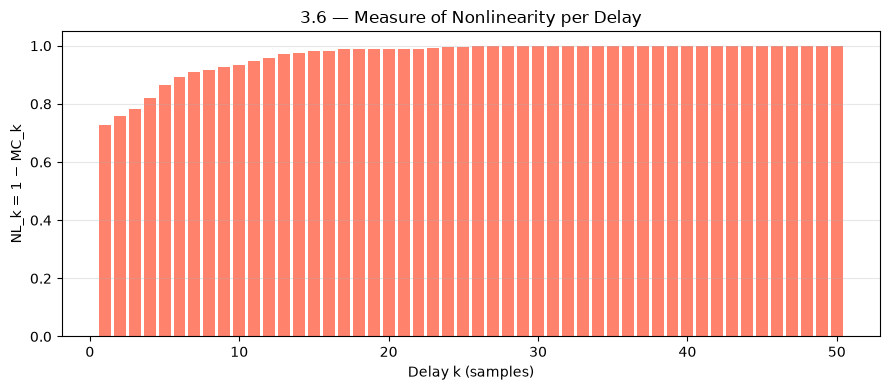

NL at k=1 (immediate-past nonlinearity): 0.7260
NL_k range across delays:                0.7260 to 0.9996
Interpretation (k=1): Mixed linear/nonlinear regime.


In [11]:
# ── 3.6 Measure of Nonlinearity ──────────────────────────
# NL_k = 1 - MC_k, one value per delay k=1..K_MAX (not a single scalar).

NL_k = 1.0 - MC_k   # shape (K_MAX,)

# ── Plot ────────────────────────────────────────────────
delays = np.arange(1, K_MAX + 1)
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(delays, NL_k, color='tomato', alpha=0.8)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel("Delay k (samples)")
ax.set_ylabel("NL_k = 1 − MC_k")
ax.set_title("3.6 — Measure of Nonlinearity per Delay")
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"NL at k=1 (immediate-past nonlinearity): {NL_k[0]:.4f}")
print(f"NL_k range across delays:                {NL_k.min():.4f} to {NL_k.max():.4f}")
if NL_k[0] < 0.2:
    print("Interpretation (k=1): Predominantly linear regime.")
elif NL_k[0] > 0.8:
    print("Interpretation (k=1): Strongly nonlinear dynamics.")
else:
    print("Interpretation (k=1): Mixed linear/nonlinear regime.")

In [12]:
# ── Section 3 Results Summary ──────────────────────────

results_s3 = {
    # Consistency
    "gamma2_global":            gamma2_global,
    "gamma2_per_electrode":     gamma2_per.tolist(),
    "ortho_shared_run":         float(ortho_shared),
    "ortho_mc":                 ortho_mc,

    # CLE
    "lambda_hat":               float(lambda_hat),
    "R2_cle":                   float(R2_cle),
    "regime_estimate":          regime,

    # PSD
    "beta_hat":                 float(beta_hat),
    "R2_psd":                   float(R2_psd),

    # MC
    "MC_total":                 float(MC_total),
    "MC_k":                     MC_k.tolist(),

    # IPC
    "IPC_total":                IPC_total,
    "IPC_by_degree":            {str(d): round(v, 6) for d, v in IPC_degree_totals.items()},

    # Nonlinearity
    "NL_k":                     NL_k.tolist(),

    # Parameters
    "test_params": {
        "SIGNAL_DURATION":  SIGNAL_DURATION,
        "K_MAX":            K_MAX,
        "IPC_MAX_DEGREE":   IPC_MAX_DEGREE,
    }
}

with open(os.path.join(RESULTS_DIR, "section3_results.json"), "w") as f:
    json.dump(results_s3, f, indent=2)

# ── Load earlier results for full summary ──────────────
print("=" * 55)
print("COMPLETE PRC CHARACTERIZATION SUMMARY")
print("=" * 55)
print(f"\n── Section 1: Fundamentals ──")
print(f"  V_safe:                      {s1['V_SAFE']:.3f}")
print(f"  H_linear power fraction:     {100*s1['H_linear_power']/s1['total_spectral_power']:.1f}%")
print(f"  H_odd power fraction:        {100*s1['H_odd_power']/s1['total_spectral_power']:.1f}%")
print(f"  H_even power fraction:       {100*s1['H_even_power']/s1['total_spectral_power']:.1f}%")
print(f"  Peak noise floor σ²_H:       {s1['noise_floor_peak_sigma2_H']:.6f}")
print(f"\n── Section 2: System Identification ──")
print(f"  Ortho (fingerprint mean):    {s2['ortho_fingerprint_mean']:.4f}")
print(f"  Ortho (FMP/ESP tests):       {s2['ortho_fmp']:.4f} / {s2['ortho_esp']:.4f}")
print(f"  SP post-spike d̄:             {s2['sp_post_spike_d_mean']:.4f}")
print(f"  SP σ/d̄:                      {s2['sp_sigma_over_d']:.4f}")
print(f"\n── Section 3: System Characterization ──")
print(f"  Consistency γ²:              {gamma2_global:.4f}")
print(f"  Ortho (shared run):          {ortho_shared:.4f}")
print(f"  CLE λ̂:                       {lambda_hat:.5f}  (R²={R2_cle:.3f})")
print(f"  Dynamical regime:            {regime}")
print(f"  PSD exponent β̂:              {beta_hat:.4f}  (R²={R2_psd:.3f})")
print(f"  Linear MC (total):           {MC_total:.4f}")
print(f"  IPC (total):                 {IPC_total:.4f}")
print(f"  Nonlinearity NL (k=1):       {NL_k[0]:.4f}  (range {NL_k.min():.4f}-{NL_k.max():.4f})")
print(f"\nAll results saved to {RESULTS_DIR}")

COMPLETE PRC CHARACTERIZATION SUMMARY

── Section 1: Fundamentals ──
  V_safe:                      0.800
  H_linear power fraction:     22.0%
  H_odd power fraction:        0.4%
  H_even power fraction:       55.5%
  Peak noise floor σ²_H:       0.000511

── Section 2: System Identification ──
  Ortho (fingerprint mean):    0.2824
  Ortho (FMP/ESP tests):       0.0053 / 0.3300
  SP post-spike d̄:             0.0190
  SP σ/d̄:                      0.7298

── Section 3: System Characterization ──
  Consistency γ²:              0.9847
  Ortho (shared run):          0.2151
  CLE λ̂:                       0.00216  (R²=0.000)
  Dynamical regime:            critical/edge
  PSD exponent β̂:              1.4161  (R²=0.854)
  Linear MC (total):           1.7658
  IPC (total):                 32.2727
  Nonlinearity NL (k=1):       0.7260  (range 0.7260-0.9996)

All results saved to results/
